In [1]:
%load_ext autoreload

%autoreload 2

In [25]:
import pandas as pd
from datetime import datetime, timedelta
from difflib import SequenceMatcher
import matplotlib.pyplot as plt
import os
from pathlib import Path
import seaborn as sns
import numpy as np
from lifelines.utils import to_long_format
from lifelines.utils import add_covariate_to_timeline
from lifelines import CoxTimeVaryingFitter
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import ks_2samp
from scipy import stats
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as mtick
from lifelines import KaplanMeierFitter
import warnings
from preproces_prod4_2025_update import *
from scipy.stats import norm
import gspread
from oauth2client.service_account import ServiceAccountCredentials
warnings.filterwarnings("ignore")


pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

In [3]:
path_actual = Path.cwd()
path_data = path_actual.parent / 'Data'

In [4]:
df_pf_2025 = pre_filtred(df_name='COHORTE_NIRSE_ACTUALIZADA_04_03_2026_ENC.csv',lrti_name='LRTI_Flag')#NAC_RNI_EGRESOS_ENTREGA_ISCI_20_12_2024_encr

n_rows_inicial= 338452
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 338452


In [5]:
df_pf_2025.query('eleg_group=="exceso_seasonal_2024_and_catchup_2025"').fechaInm.dt.year.value_counts()

fechaInm
2025.0    22714
2024.0    15133
Name: count, dtype: int64

In [9]:
df_pf_2025.query('eleg_group=="exceso_seasonal_2024_and_catchup_2025"').assign(mes_inm = lambda x: x.fechaInm.dt.month_name()).groupby(['mes_nac_name','mes_inm']).RUN.nunique().unstack('mes_nac_name')

mes_nac_name,December,November,October
mes_inm,,,
April,4599.0,2226.0,330.0
August,77.0,46.0,12.0
December,2.0,102.0,19.0
February,1.0,NaN,NaN
January,NaN,5.0,1.0
July,212.0,120.0,49.0
June,384.0,279.0,104.0
March,5086.0,4954.0,274.0
May,1062.0,600.0,197.0


In [19]:
df_f_any, df_f_LRTI, df_f_vrs_25, df_f_upc_25 = filtros_IH_new(df_pf_2025,
                                                               eliminar_inmunes_pre_season=True, 
                                                               T_inicial = pd.to_datetime('2025-03-01'), 
                                                               fecha_dt=pd.to_datetime('2025-09-30'),
                                                               fecha_cohort_in=pd.to_datetime('2024-10-01'),
                                                               fecha_cohort_out=pd.to_datetime('2025-09-30'))

Datos perdidos por muertes:  1096
ruts perdidos por filtro semanas y peso:  593
Droped intersex: 11
Datos perdidos por edad madre atípica: 270
Datos perdidos por fecha ingreso menor a fecha nacimiento: 12
vrs en los primeros 7 dias de nacer: 1
Ruts eliminados: 18171
fechaIng_vrs Reemplazos n/a net 7 days inmunizado:  8
fecha_upc_vrs Reemplazos n/a net 7 days inmunizado:  8
fechaIng_LRTI Reemplazos n/a net 7 days inmunizado:  13
fechaIng_any Reemplazos n/a net 7 days inmunizado:  458
max_meses_inm = 6


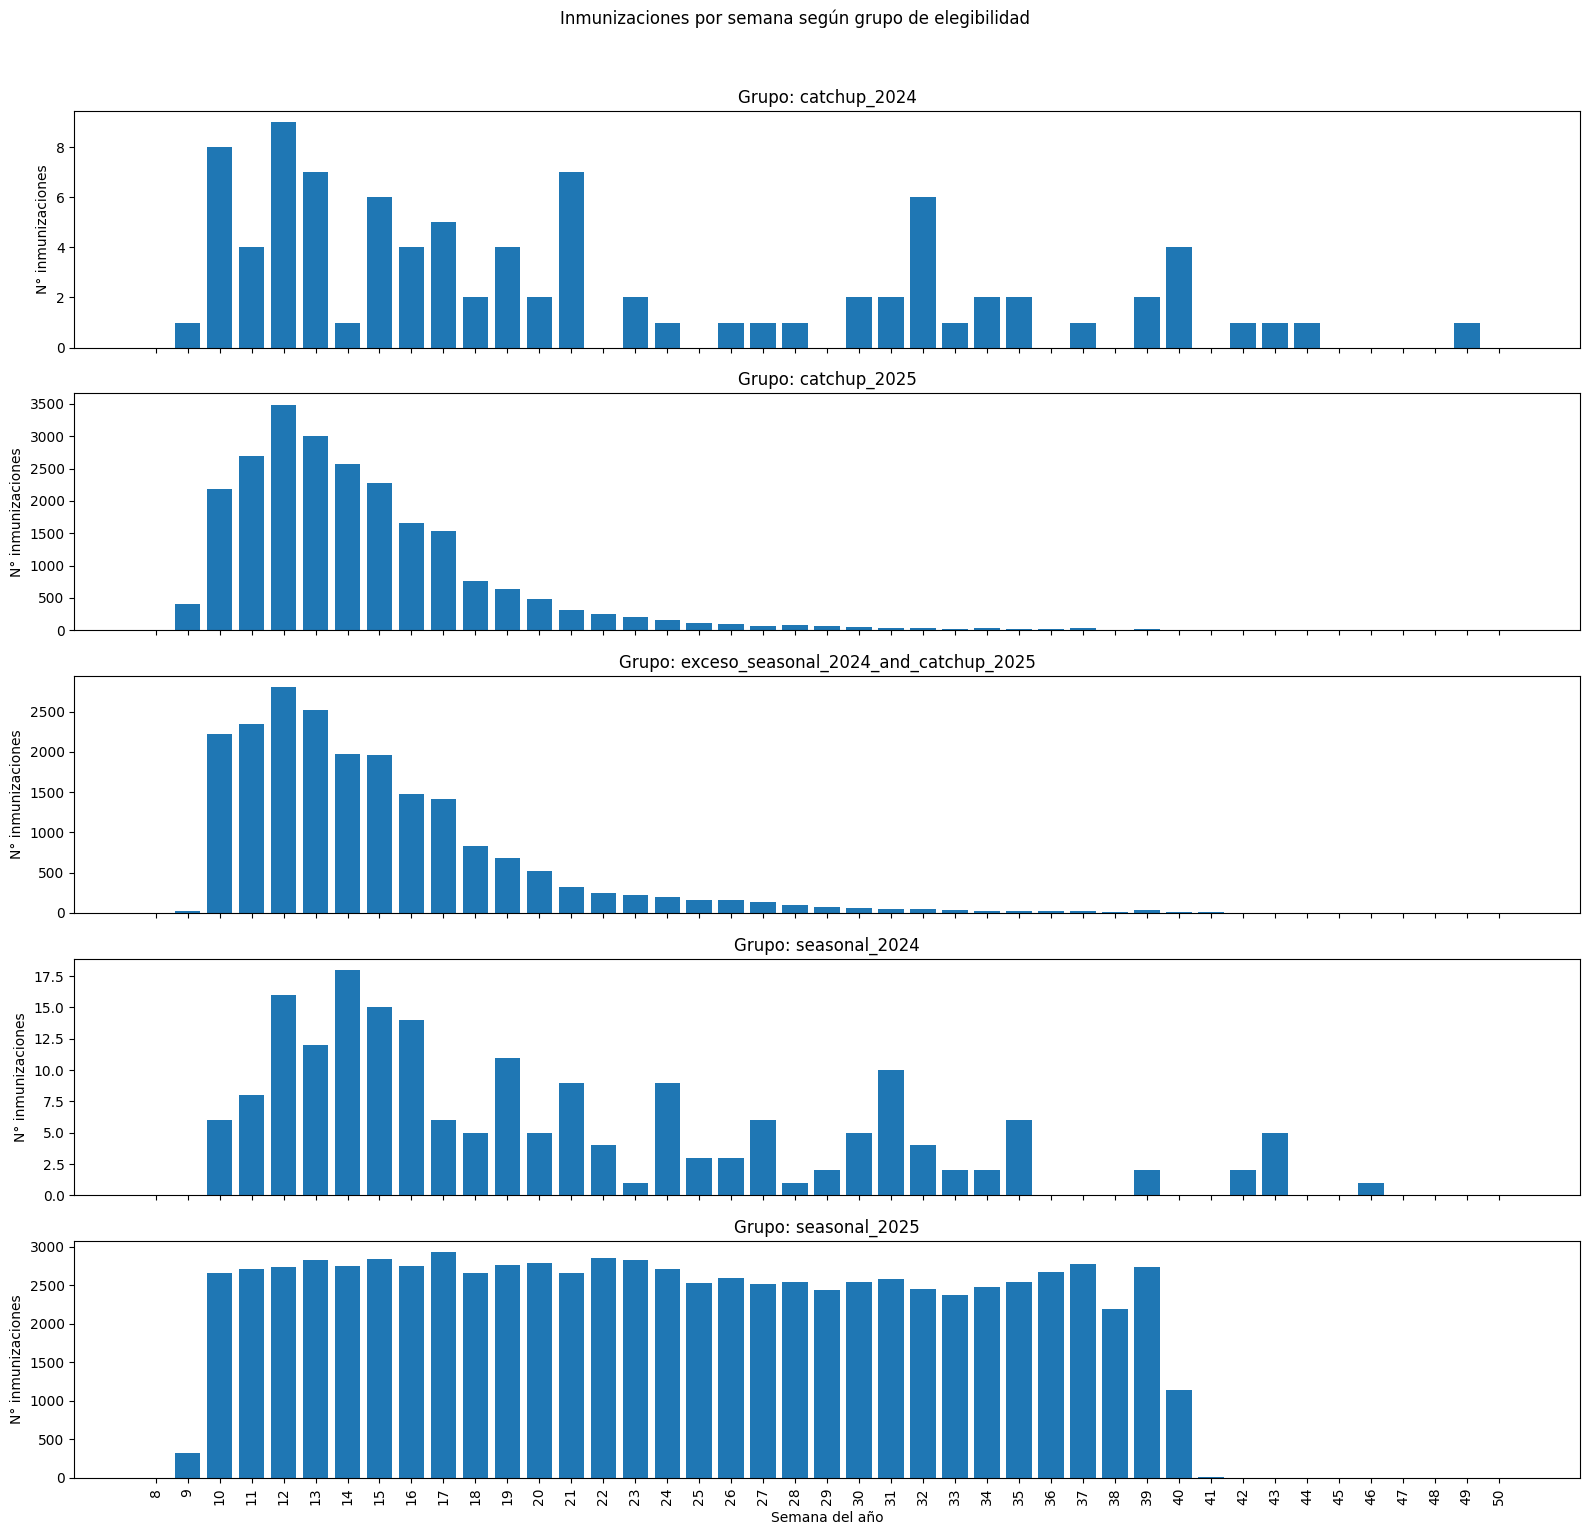

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Preparación de datos
# -----------------------------
df_plot = (
    df_pf_2025
    .dropna(subset=['fechaInm'])
    .assign(
        ano_inm=lambda d: d.fechaInm.dt.year,
        semana=lambda d: d.fechaInm.dt.isocalendar().week.astype(int)
    )
    .query('ano_inm==2025')
)

weekly_counts = (
    df_plot
    .groupby(['eleg_group', 'semana'])
    .RUN.nunique()
    .reset_index(name='n')
)

groups = sorted(weekly_counts['eleg_group'].unique())
weeks = np.arange(8, 51)

# -----------------------------
# Subplots: uno por eleg_group
# -----------------------------
fig, axes = plt.subplots(
    nrows=len(groups),
    ncols=1,
    figsize=(16, 3 * len(groups)),
    sharex=True
)

# Si hay solo un grupo, axes no es iterable
if len(groups) == 1:
    axes = [axes]

for ax, group in zip(axes, groups):
    y = (
        weekly_counts
        .loc[weekly_counts['eleg_group'] == group]
        .set_index('semana')
        .reindex(weeks, fill_value=0)['n']
    )

    ax.bar(
        weeks,
        y,
        width=0.8
    )

    ax.set_title(f"Grupo: {group}")
    ax.set_ylabel("N° inmunizaciones")

# -----------------------------
# Ejes comunes y formato
# -----------------------------
axes[-1].set_xlabel("Semana del año")
axes[-1].set_xticks(weeks)
axes[-1].set_xticklabels(weeks, rotation=90)

fig.suptitle("Inmunizaciones por semana según grupo de elegibilidad", y=1.02)

plt.tight_layout()
plt.show()


EMPIEZO A REPLICAR COSAS DE PAPER PASADO...

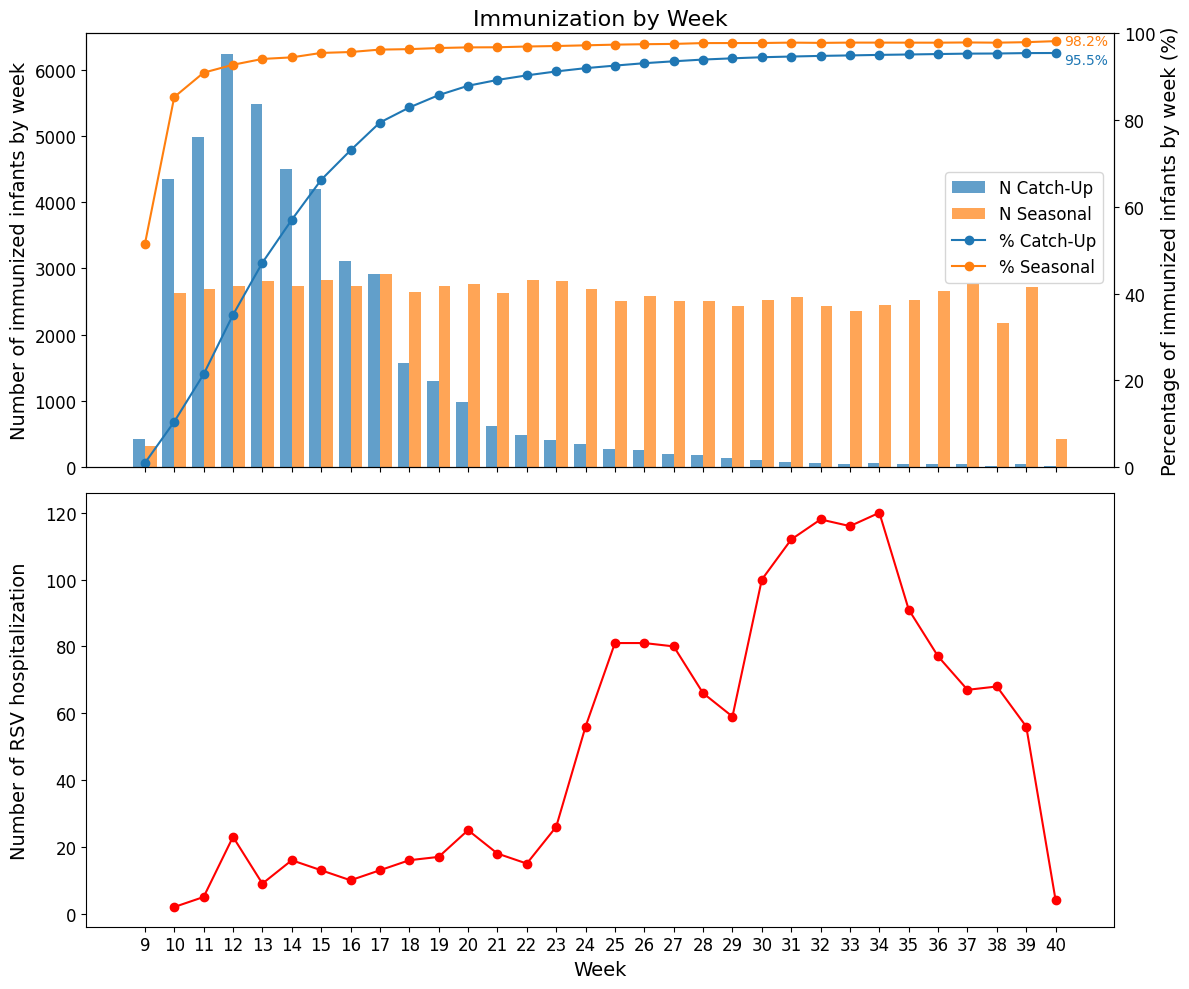

In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Datos originales del primer gráfico
df_vrs_tilweek_edit = df_f_vrs_sep.copy()

nacimientos_normal = (
    df_vrs_tilweek_edit
    .assign(
        week=lambda x: np.where(
            x.fecha_nac.dt.isocalendar().year == 2025, 
            x.fecha_nac.dt.isocalendar().week, 
            x.fecha_nac.dt.isocalendar().week.min()
        )
    )
    .groupby(['eleg_2025', 'week'])
    .size()
    .unstack(0)
    .fillna(0)
    .query("week >= 8")
)

nacimientos_cumsum = (
    df_vrs_tilweek_edit
    .assign(
        week=lambda x: np.where(
            x.fecha_nac.dt.isocalendar().year == 2025, 
            x.fecha_nac.dt.isocalendar().week, 
            x.fecha_nac.dt.isocalendar().week.min()
        )
    )
    .groupby(['eleg_2025', 'week'])
    .size()
    .reset_index(name='count')
    .pivot(index='week', columns='eleg_2025', values='count')
    .fillna(0)
    .cumsum()
    .query("week >= 8")
)

# Incorporamos valores acumulados en nacimientos_normal
nacimientos_normal['CATCH_UP'] = nacimientos_cumsum['CATCH_UP']
nacimientos_normal['SEASONAL'] = nacimientos_cumsum['SEASONAL']

grafico_campaign = (
    df_vrs_tilweek_edit
    .query('fechaInm.notna()')
    # .assign(week = lambda x: np.where(x.fechaInm.dt.isocalendar().week==13,
    #                                   x.fechaInm.dt.isocalendar().week+1,
    #                                   x.fechaInm.dt.isocalendar().week))
    .assign(week = lambda x: x.fechaInm.dt.isocalendar().week)
    .groupby(['eleg_2025','week'])
    .size()
    .unstack(0)
    .fillna(0)
    .merge(nacimientos_normal, how='left', on=['week'])
    .rename(columns={
        'CATCH_UP_x': 'Catch_Campaña',
        'SEASONAL_x': 'Seasonal_Campaña',
        'CATCH_UP_y': 'Catch_Nacimientos',
        'SEASONAL_y': 'Seasonal_Nacimientos'
    })
    # Porcentajes acumulados
    .assign(Porcentaje_inmune_catchup = lambda x: 100 * x['Catch_Campaña'].cumsum() / x['Catch_Nacimientos'],
            Porcentaje_inmune_seasonal = lambda x: 100 * x['Seasonal_Campaña'].cumsum() / x['Seasonal_Nacimientos'])
    .reset_index()
)

df = grafico_campaign


# Datos para el segundo gráfico (RSV)
vrs_normal = (
    df_vrs_tilweek_edit
    .query('fechaIng_vrs.notna()')
    .assign(
        week=lambda x: x.fechaIng_vrs.dt.isocalendar().week
    )
    .groupby(['week'], as_index=False)
    .size()
    .rename(columns={'size':'casos_vrs'})
    .fillna(0)
)

# Suavizamos un poco la serie de casos VRS usando un rolling mean
# (ajusta la ventana como desees)
vrs_normal['casos_vrs_suav'] = vrs_normal['casos_vrs'].rolling(window=1, center=True).mean()
# Llenamos valores NaN al inicio y fin (por la ventana de rolling) para no tener "huecos"
vrs_normal['casos_vrs_suav'] = vrs_normal['casos_vrs_suav'].fillna(method='bfill').fillna(method='ffill')


# Creamos la figura con dos subplots, compartiendo el eje X
fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

#### GRÁFICO SUPERIOR (inmunización) ####
catch_color = '#1f77b4'    # Azul (Catch)
seasonal_color = '#ff7f0e' # Naranja (Seasonal)

bar1 = ax_top.bar(df['week'] - 0.2, df['Catch_Campaña'], width=0.4, label='N Catch-Up', color=catch_color, alpha=0.7)
bar2 = ax_top.bar(df['week'] + 0.2, df['Seasonal_Campaña'], width=0.4, label='N Seasonal', color=seasonal_color, alpha=0.7)

ax_top.set_ylabel('Number of immunized infants by week', color='black', fontsize=14)
ax_top.tick_params(axis='x', labelsize=12)
ax_top.tick_params(axis='y', labelsize=12)
ax_top.set_xticks(df['week'])

ax_top2 = ax_top.twinx()
line1, = ax_top2.plot(df['week'], df['Porcentaje_inmune_catchup'], marker='o', color=catch_color, label='% Catch-Up')
line2, = ax_top2.plot(df['week'], df['Porcentaje_inmune_seasonal'], marker='o', color=seasonal_color, label='% Seasonal')
ax_top2.set_ylabel('Percentage of immunized infants by week (%)', color='black', fontsize=14)
ax_top2.tick_params(axis='y', labelsize=12)
ax_top2.set_ylim(0, 100)

# Texto final en las curvas
last_week = df['week'].iloc[-1]
final_catchup = df['Porcentaje_inmune_catchup'].iloc[-1]
final_seasonal = df['Porcentaje_inmune_seasonal'].iloc[-1]

ax_top2.text(last_week + 0.3, final_catchup, f'{final_catchup:.1f}%', color=catch_color, va='top', fontsize=10)
ax_top2.text(last_week + 0.3, final_seasonal, f'{final_seasonal:.1f}%', color=seasonal_color, va='center', fontsize=10)

lines = [bar1, bar2, line1, line2]
labels = ['N Catch-Up', 'N Seasonal', '% Catch-Up', '% Seasonal']
fig.legend(lines, labels, loc='upper right', ncol=1, bbox_to_anchor=(0.93, 0.83), fontsize=12)

ax_top.set_title('Immunization by Week', fontsize=16)


#### GRÁFICO INFERIOR (RSV) ####
# Graficamos la línea suavizada de casos de VRS
ax_bottom.plot(vrs_normal['week'], vrs_normal['casos_vrs_suav'], marker='o', color='red', label='RSV Hospitalization')
ax_bottom.set_ylabel('Number of RSV hospitalization', fontsize=14)
ax_bottom.tick_params(axis='y', labelsize=12)
ax_bottom.tick_params(axis='x', labelsize=12)
ax_bottom.set_xlabel('Week', fontsize=14)

# Ajustamos el layout
plt.tight_layout()
# plt.savefig(path_data/'immunization_and_circulation_by_week.png', dpi=400)
# plt.savefig(path_data/'immunization_and_circulation_by_week.eps', format='eps')
fig.align_ylabels([ax_top, ax_bottom])
plt.show()

In [22]:
df_f = df_f_vrs_25

region_to_macrozone_isci = {
    "ARICA Y PARINACOTA": "Macrozona Norte",
    "TARAPACA": "Macrozona Norte",
    "ANTOFAGASTA": "Macrozona Norte",
    "ATACAMA": "Macrozona Norte",
    "COQUIMBO": "Macrozona Centro",
    "VALPARAISO": "Macrozona Centro",
    "METROPOLITANA": "Macrozona Centro",
    "O'HIGGINS": "Macrozona Centro",
    "MAULE": "Macrozona Sur",
    "NUBLE": "Macrozona Sur",
    "BIOBIO": "Macrozona Sur",
    "ARAUCANIA": "Macrozona Sur",
    "LOS RIOS": "Macrozona Sur",
    "LOS LAGOS": "Macrozona Sur",
    "AISEN": "Macrozona Austral",
    "MAGALLANES Y ANTARTICA": "Macrozona Austral"
}

df_f["macrozona_isci"] = df_f["region"].map(region_to_macrozone_isci)

T_final_tabla = pd.to_datetime('2025-09-30')
df_f['nacionalidad_madre'] = np.where(df_f['NAC_MA']=='C','Domestic' , np.where(df_f['NAC_MA']=='E','Foreign' ,'Unknown'))
df_f['time_to_imune'] = np.where(df_f.eleg_2025=='SEASONAL', (df_f['fechaInm'] - df_f['fecha_nac']).dt.days, (df_f['fechaInm'] - pd.to_datetime("2025-03-01")).dt.days)
df_f['age_at_cut_days'] = ((T_final_tabla - df_f['fecha_nac']).dt.days)
df_f['age_at_cut'] = df_f.age_at_cut_days / 30
df_f['ages_group'] = np.where(df_f['age_at_cut_days'] < 90, 1, np.where(df_f['age_at_cut_days'] <= 180, 2, 3))

total_overall = df_f.RUN.nunique()
total_non_recipients = df_f[df_f['inmunizado'] == 0].RUN.nunique()
total_recipients = df_f[df_f['inmunizado'] == 1].RUN.nunique()

age_all = df_f['ages_group'].value_counts()
age_no_reci= df_f[df_f['inmunizado'] == 0]['ages_group'].value_counts()
age_reci = df_f[df_f['inmunizado'] == 1]['ages_group'].value_counts()

sex_counts_overall = df_f['sexo'].value_counts()
sex_counts_non_recipients = df_f[df_f['inmunizado'] == 0]['sexo'].value_counts()
sex_counts_recipients = df_f[df_f['inmunizado'] == 1]['sexo'].value_counts()

nationality_counts_overall = df_f['eleg_2025'].value_counts()
nationality_counts_non_recipients = df_f[df_f['inmunizado'] == 0]['eleg_2025'].value_counts()
nationality_counts_recipients = df_f[df_f['inmunizado'] == 1]['eleg_2025'].value_counts()
nationality_mother_counts_overall = df_f['nacionalidad_madre'].value_counts()
nationality_mother_counts_non_recp = df_f[df_f['inmunizado'] == 0]['nacionalidad_madre'].value_counts()
nationality_mother_counts_recipients = df_f[df_f['inmunizado'] == 1]['nacionalidad_madre'].value_counts()

# Edad gestacional al nacer (semanas)
mean_sd_overall = (df_f['SEMANAS'].mean(), df_f['SEMANAS'].std())
mean_sd_non_recipients = (df_f[df_f['inmunizado'] == 0]['SEMANAS'].mean(), df_f[df_f['inmunizado'] == 0]['SEMANAS'].std())
mean_sd_recipients = (df_f[df_f['inmunizado'] == 1]['SEMANAS'].mean(), df_f[df_f['inmunizado'] == 1]['SEMANAS'].std())

median_overall = df_f['SEMANAS'].median()
median_non_recipients = df_f[df_f['inmunizado'] == 0]['SEMANAS'].median()
median_recipients = df_f[df_f['inmunizado'] == 1]['SEMANAS'].median()

# weight 
w_mean_sd_overall = (df_f['PESO'].mean(), df_f['PESO'].std())
w_mean_sd_non_recipients = (df_f[df_f['inmunizado'] == 0]['PESO'].mean(), df_f[df_f['inmunizado'] == 0]['PESO'].std())
w_mean_sd_recipients = (df_f[df_f['inmunizado'] == 1]['PESO'].mean(), df_f[df_f['inmunizado'] == 1]['PESO'].std())

w_median_overall = df_f['PESO'].median()
w_median_non_recipients = df_f[df_f['inmunizado'] == 0]['PESO'].median()
w_median_recipients = df_f[df_f['inmunizado'] == 1]['PESO'].median()

# preterm
df_f['preterm'] = np.where(df_f['SEMANAS']<37, 1, 0)
preterm_counts_overall = df_f['preterm'].value_counts()
preterm_counts_non_recipients = df_f[df_f['inmunizado'] == 0]['preterm'].value_counts()
preterm_counts_recipients = df_f[df_f['inmunizado'] == 1]['preterm'].value_counts()

macrozone_all = df_f['macrozona_isci'].value_counts()
macrozone_no_reci= df_f[df_f['inmunizado'] == 0]['macrozona_isci'].value_counts()
macrozone_reci = df_f[df_f['inmunizado'] == 1]['macrozona_isci'].value_counts()

time_inm_mean_sd_overall = (df_f['time_to_imune'].mean(), df_f['time_to_imune'].std())
time_inm_mean_sd_non_recipients = (df_f[df_f['inmunizado'] == 0]['time_to_imune'].mean(), df_f[df_f['inmunizado'] == 0]['time_to_imune'].std())
time_inm_mean_sd_recipients = (df_f[df_f['inmunizado'] == 1]['time_to_imune'].mean(), df_f[df_f['inmunizado'] == 1]['time_to_imune'].std())

time_inm_median_overall = df_f['time_to_imune'].median()
time_inm_median_non_recipients = df_f[df_f['inmunizado'] == 0]['time_to_imune'].median()
time_inm_median_recipients = df_f[df_f['inmunizado'] == 1]['time_to_imune'].median()

# Ahora calculamos mean y sd de time_to_imune por grupo (CATCH_UP y SEASONAL)
catchup_overall = df_f[df_f['eleg_2025'] == 'CATCH_UP']['time_to_imune']
seasonal_overall = df_f[df_f['eleg_2025'] == 'SEASONAL']['time_to_imune']

catchup_overall_mean_sd = (catchup_overall.median(), catchup_overall.quantile(0.75) - catchup_overall.quantile(0.25))
seasonal_overall_mean_sd = (seasonal_overall.median(), seasonal_overall.quantile(0.75) - seasonal_overall.quantile(0.25))

catchup_non_recipients = df_f[(df_f['inmunizado'] == 0) & (df_f['eleg_2025'] == 'CATCH_UP')]['time_to_imune']
catchup_non_rec_mean_sd = (catchup_non_recipients.median(), catchup_non_recipients.quantile(0.75) - catchup_non_recipients.quantile(0.25))

catchup_recipients = df_f[(df_f['inmunizado'] == 1) & (df_f['eleg_2025'] == 'CATCH_UP')]['time_to_imune']
catchup_rec_mean_sd = (catchup_recipients.median(), catchup_recipients.quantile(0.75) - catchup_recipients.quantile(0.25))

seasonal_non_recipients = df_f[(df_f['inmunizado'] == 0) & (df_f['eleg_2025'] == 'SEASONAL')]['time_to_imune']
seasonal_non_rec_mean_sd = (seasonal_non_recipients.median(), seasonal_non_recipients.quantile(0.75) - seasonal_non_recipients.quantile(0.25))

seasonal_recipients = df_f[(df_f['inmunizado'] == 1) & (df_f['eleg_2025'] == 'SEASONAL')]['time_to_imune']
seasonal_rec_mean_sd = (seasonal_recipients.median(), seasonal_recipients.quantile(0.75) - seasonal_recipients.quantile(0.25))

column_tuples = [
    ("Overall", f"(N={total_overall})"),
    ("Nirse recipients", f"(N={total_recipients})"),
    ("Nirse non recipients", f"(N={total_non_recipients})"),
    ("p-value", "")
]

# Convertir las tuplas en un MultiIndex para las columnas
columns = pd.MultiIndex.from_tuples(column_tuples)

# Modificar la estructura de la tabla: en vez de Mean(SD) y Median en Time to immune,
# ahora tendremos "Catch-up" y "Seasonal".
row_index = pd.MultiIndex.from_tuples([
    ("Ages (Months)", ""),
    ("", "<3"),
    ("", "3 to 6"),
    ("", ">6"),
    ("","median (IQR)"),
    ("Sex", ""),
    ("", "Female"),
    ("", "Male"),
    ("Nationality mother", ""),
    ("", "Foreign"),
    ("", "Domestic"),
    ("", "Unknown"),
    ("Season group", ""),
    ("", "Catch-up"),
    ("", "Seasonal"),
    ("Time to immune (days)", ""), 
    (" ", "Catch-up"),    # Nueva fila en vez de Mean (SD)
    (" ", "Seasonal"),    # Nueva fila en vez de Median
    ("Gestational Age at birth (days)", ""),
    (" ", "Mean (SD)"),
    #(" ", "Median"),
    ("Weight at birth (gr)", ""),
    ("  ", "Mean (SD)"),
    #("  ", "Median"),
    ("Preterm", ""),
    ("", "No (>= 37 weeks)"),
    ("", "Yes (< 37 weeks)"),
    ("Macro-zones", ""),
    ("", "North"),
    ("", "Central"),
    ("", "South"),
    ("", "Austral")
])

df_table = pd.DataFrame(index=row_index, columns=columns)

def val_pct(value, total):
    return f"{value} ({(value*100/total):.2f}%)"

# Edades
df_table.loc[("", "<3"), ("Overall", f"(N={total_overall})")] = val_pct(age_all.get(1,0), total_overall)
df_table.loc[("", "<3"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(age_no_reci.get(1,0), total_non_recipients)
df_table.loc[("", "<3"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(age_reci.get(1,0), total_recipients)

df_table.loc[("", "3 to 6"), ("Overall", f"(N={total_overall})")] = val_pct(age_all.get(2,0), total_overall)
df_table.loc[("", "3 to 6"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(age_no_reci.get(2,0), total_non_recipients)
df_table.loc[("", "3 to 6"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(age_reci.get(2,0), total_recipients)

df_table.loc[("", ">6"), ("Overall", f"(N={total_overall})")] = val_pct(age_all.get(3,0), total_overall)
df_table.loc[("", ">6"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(age_no_reci.get(3,0), total_non_recipients)
df_table.loc[("", ">6"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(age_reci.get(3,0), total_recipients)

# df_table.loc[("","median (IQR)"), ("Overall", f"(N={total_overall})")] = f"{df_f['age_at_cut'].median():.2f} ({(df_f['age_at_cut'].quantile(0.25)):.2f} - {(df_f['age_at_cut'].quantile(0.75)):.2f}) ({(df_f['age_at_cut'].quantile(0.75) - df_f['age_at_cut'].quantile(0.25)):.2f})" 
# df_table.loc[("","median (IQR)"), ("Nirse non recipients", f"(N={total_non_recipients})")] = f"{df_f[df_f['inmunizado'] == 0]['age_at_cut'].median():.2f} ({(df_f[df_f['inmunizado'] == 0]['age_at_cut'].quantile(0.75) - df_f[df_f['inmunizado'] == 0]['age_at_cut'].quantile(0.25)):.2f})" 
# df_table.loc[("","median (IQR)"), ("Nirse recipients", f"(N={total_recipients})")] = f"{df_f[df_f['inmunizado'] == 1]['age_at_cut'].median():.2f} ({(df_f[df_f['inmunizado'] == 1]['age_at_cut'].quantile(0.75) - df_f[df_f['inmunizado'] == 1]['age_at_cut'].quantile(0.25)):.2f})"

df_table.loc[("","median (IQR)"), ("Overall", f"(N={total_overall})")] = f"{df_f['age_at_cut'].median():.2f} ({(df_f['age_at_cut'].quantile(0.25)):.2f} - {(df_f['age_at_cut'].quantile(0.75)):.2f})" 
df_table.loc[("","median (IQR)"), ("Nirse non recipients", f"(N={total_non_recipients})")] = f"{df_f[df_f['inmunizado'] == 0]['age_at_cut'].median():.2f} ({(df_f[df_f['inmunizado'] == 0]['age_at_cut'].quantile(0.25)):.2f} - {(df_f[df_f['inmunizado'] == 0]['age_at_cut'].quantile(0.75)):.2f})" 
df_table.loc[("","median (IQR)"), ("Nirse recipients", f"(N={total_recipients})")] = f"{df_f[df_f['inmunizado'] == 1]['age_at_cut'].median():.2f} ({(df_f[df_f['inmunizado'] == 1]['age_at_cut'].quantile(0.25)):.2f} - {(df_f[df_f['inmunizado'] == 1]['age_at_cut'].quantile(0.75)):.2f})"

# Sexo
df_table.loc[("", "Female"), ("Overall", f"(N={total_overall})")] = val_pct(sex_counts_overall.get(0, 0), total_overall)
df_table.loc[("", "Female"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(sex_counts_non_recipients.get(0, 0), total_non_recipients)
df_table.loc[("", "Female"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(sex_counts_recipients.get(0, 0), total_recipients)

df_table.loc[("", "Male"), ("Overall", f"(N={total_overall})")] = val_pct(sex_counts_overall.get(1, 0), total_overall)
df_table.loc[("", "Male"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(sex_counts_non_recipients.get(1, 0), total_non_recipients)
df_table.loc[("", "Male"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(sex_counts_recipients.get(1, 0), total_recipients)

# Season group
df_table.loc[("", "Catch-up"), ("Overall", f"(N={total_overall})")] = val_pct(nationality_counts_overall.get('CATCH_UP', 0), total_overall)
df_table.loc[("", "Seasonal"), ("Overall", f"(N={total_overall})")] = val_pct(nationality_counts_overall.get('SEASONAL', 0), total_overall)

df_table.loc[("", "Catch-up"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(nationality_counts_non_recipients.get('CATCH_UP', 0), total_non_recipients)
df_table.loc[("", "Seasonal"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(nationality_counts_non_recipients.get('SEASONAL', 0), total_non_recipients)

df_table.loc[("", "Catch-up"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(nationality_counts_recipients.get('CATCH_UP', 0), total_recipients)
df_table.loc[("", "Seasonal"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(nationality_counts_recipients.get('SEASONAL', 0), total_recipients)

# Nationality mother
df_table.loc[("", "Foreign"), ("Overall", f"(N={total_overall})")] = val_pct(nationality_mother_counts_overall.get('Foreign', 0), total_overall)
df_table.loc[("", "Domestic"), ("Overall", f"(N={total_overall})")] = val_pct(nationality_mother_counts_overall.get('Domestic', 0), total_overall)
df_table.loc[("", "Unknown"), ("Overall", f"(N={total_overall})")] = val_pct(nationality_mother_counts_overall.get('Unknown', 0), total_overall)

df_table.loc[("", "Foreign"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(nationality_mother_counts_non_recp.get('Foreign', 0), total_non_recipients)
df_table.loc[("", "Domestic"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(nationality_mother_counts_non_recp.get('Domestic', 0), total_non_recipients)
df_table.loc[("", "Unknown"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(nationality_mother_counts_non_recp.get('Unknown', 0), total_non_recipients)

df_table.loc[("", "Foreign"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(nationality_mother_counts_recipients.get('Foreign', 0), total_recipients)
df_table.loc[("", "Domestic"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(nationality_mother_counts_recipients.get('Domestic', 0), total_recipients)
df_table.loc[("", "Unknown"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(nationality_mother_counts_recipients.get('Unknown', 0), total_recipients)

# Gestational Age at birth (days) - sin cambios
df_table.loc[(" ", "Mean (SD)"), ("Overall", f"(N={total_overall})")] = f"{mean_sd_overall[0]:.2f} ({mean_sd_overall[1]:.2f})"
df_table.loc[(" ", "Mean (SD)"), ("Nirse non recipients", f"(N={total_non_recipients})")] = f"{mean_sd_non_recipients[0]:.2f} ({mean_sd_non_recipients[1]:.2f})"
df_table.loc[(" ", "Mean (SD)"), ("Nirse recipients", f"(N={total_recipients})")] = f"{mean_sd_recipients[0]:.2f} ({mean_sd_recipients[1]:.2f})"

# df_table.loc[(" ", "Median"), ("Overall", f"(N={total_overall})")] = median_overall
# df_table.loc[(" ", "Median"), ("Nirse non recipients", f"(N={total_non_recipients})")] = median_non_recipients
# df_table.loc[(" ", "Median"), ("Nirse recipients", f"(N={total_recipients})")] = median_recipients

# Weight at birth (gr)
df_table.loc[("  ", "Mean (SD)"), ("Overall", f"(N={total_overall})")] = f"{w_mean_sd_overall[0]:.2f} ({w_mean_sd_overall[1]:.2f})"
df_table.loc[("  ", "Mean (SD)"), ("Nirse non recipients", f"(N={total_non_recipients})")] = f"{w_mean_sd_non_recipients[0]:.2f} ({w_mean_sd_non_recipients[1]:.2f})"
df_table.loc[("  ", "Mean (SD)"), ("Nirse recipients", f"(N={total_recipients})")] = f"{w_mean_sd_recipients[0]:.2f} ({w_mean_sd_recipients[1]:.2f})"

# df_table.loc[("  ", "Median"), ("Overall", f"(N={total_overall})")] = w_median_overall
# df_table.loc[("  ", "Median"), ("Nirse non recipients", f"(N={total_non_recipients})")] = w_median_non_recipients
# df_table.loc[("  ", "Median"), ("Nirse recipients", f"(N={total_recipients})")] = w_median_recipients

# Preterm
df_table.loc[("", "No (>= 37 weeks)"), ("Overall", f"(N={total_overall})")] = val_pct(preterm_counts_overall.get(0, 0), total_overall)
df_table.loc[("", "No (>= 37 weeks)"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(preterm_counts_non_recipients.get(0, 0), total_non_recipients)
df_table.loc[("", "No (>= 37 weeks)"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(preterm_counts_recipients.get(0, 0), total_recipients)

df_table.loc[("", "Yes (< 37 weeks)"), ("Overall", f"(N={total_overall})")] = val_pct(preterm_counts_overall.get(1, 0), total_overall)
df_table.loc[("", "Yes (< 37 weeks)"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(preterm_counts_non_recipients.get(1, 0), total_non_recipients)
df_table.loc[("", "Yes (< 37 weeks)"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(preterm_counts_recipients.get(1, 0), total_recipients)

# Macro-zones
df_table.loc[("", "North"), ("Overall", f"(N={total_overall})")] = val_pct(macrozone_all.get('Macrozona Norte',0), total_overall)
df_table.loc[("", "North"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(macrozone_no_reci.get('Macrozona Norte',0), total_non_recipients)
df_table.loc[("", "North"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(macrozone_reci.get('Macrozona Norte',0), total_recipients)

df_table.loc[("", "Central"), ("Overall", f"(N={total_overall})")] = val_pct(macrozone_all.get('Macrozona Centro',0), total_overall)
df_table.loc[("", "Central"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(macrozone_no_reci.get('Macrozona Centro',0), total_non_recipients)
df_table.loc[("", "Central"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(macrozone_reci.get('Macrozona Centro',0), total_recipients)

df_table.loc[("", "South"), ("Overall", f"(N={total_overall})")] = val_pct(macrozone_all.get('Macrozona Sur',0), total_overall)
df_table.loc[("", "South"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(macrozone_no_reci.get('Macrozona Sur',0), total_non_recipients)
df_table.loc[("", "South"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(macrozone_reci.get('Macrozona Sur',0), total_recipients)

df_table.loc[("", "Austral"), ("Overall", f"(N={total_overall})")] = val_pct(macrozone_all.get('Macrozona Austral',0), total_overall)
df_table.loc[("", "Austral"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(macrozone_no_reci.get('Macrozona Austral',0), total_non_recipients)
df_table.loc[("", "Austral"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(macrozone_reci.get('Macrozona Austral',0), total_recipients)

# Time to immune (days) ahora con Catch-up y Seasonal (Mean(SD))
df_table.loc[(" ", "Catch-up"), ("Overall", f"(N={total_overall})")] = f"{catchup_overall_mean_sd[0]:.2f} ({catchup_overall_mean_sd[1]:.2f})"
df_table.loc[(" ", "Catch-up"), ("Nirse non recipients", f"(N={total_non_recipients})")] = f"{catchup_non_rec_mean_sd[0]:.2f} ({catchup_non_rec_mean_sd[1]:.2f})"
df_table.loc[(" ", "Catch-up"), ("Nirse recipients", f"(N={total_recipients})")] = f"{catchup_rec_mean_sd[0]:.2f} ({catchup_rec_mean_sd[1]:.2f})"

df_table.loc[(" ", "Seasonal"), ("Overall", f"(N={total_overall})")] = f"{seasonal_overall_mean_sd[0]:.2f} ({seasonal_overall_mean_sd[1]:.2f})"
df_table.loc[(" ", "Seasonal"), ("Nirse non recipients", f"(N={total_non_recipients})")] = f"{seasonal_non_rec_mean_sd[0]:.2f} ({seasonal_non_rec_mean_sd[1]:.2f})"
df_table.loc[(" ", "Seasonal"), ("Nirse recipients", f"(N={total_recipients})")] = f"{seasonal_rec_mean_sd[0]:.2f} ({seasonal_rec_mean_sd[1]:.2f})"

df_table


Overall  \
                                                          (N=126625)   
Ages (Months)                                                    NaN   
                                <3                    32120 (25.37%)   
                                3 to 6                35724 (28.21%)   
                                >6                    58781 (46.42%)   
                                median (IQR)      5.63 (2.93 - 8.27)   
Sex                                                              NaN   
                                Female                62197 (49.12%)   
                                Male                  64428 (50.88%)   
Nationality mother                                               NaN   
                                Foreign               14429 (11.40%)   
                                Domestic             104156 (82.26%)   
                                Unknown                 8040 (6.35%)   
Season group                                                     NaN   
                                Catch-up              45558 (35.98%)   
                                Seasonal              81067 (64.02%)   
Time to immune (days)                                            NaN   
                                Catch-up               30.00 (31.00)   
                                Seasonal                 1.00 (1.00)   
Gestational Age at birth (days)                                  NaN   
                                Mean (SD)               38.17 (1.75)   
Weight at birth (gr)                                             NaN   
                                Mean (SD)           3276.27 (532.31)   
Preterm                                                          NaN   
                                No (>= 37 weeks)     114014 (90.04%)   
                                Yes (< 37 weeks)       12611 (9.96%)   
Macro-zones                                                      NaN   
                                North                 13321 (10.52%)   
                                Central               75995 (60.02%)   
                                South                 35713 (28.20%)   
                                Austral                 1594 (1.26%)   

                                                    Nirse recipients  \
                                                          (N=123101)   
Ages (Months)                                                    NaN   
                                <3                    31352 (25.47%)   
                                3 to 6                35182 (28.58%)   
                                >6                    56567 (45.95%)   
                                median (IQR)      5.60 (2.93 - 8.20)   
Sex                                                              NaN   
                                Female                60513 (49.16%)   
                                Male                  62588 (50.84%)   
Nationality mother                                               NaN   
                                Foreign               13900 (11.29%)   
                                Domestic             101175 (82.19%)   
                                Unknown                 8026 (6.52%)   
Season group                                                     NaN   
                                Catch-up              43492 (35.33%)   
                                Seasonal              79609 (64.67%)   
Time to immune (days)                                            NaN   
                                Catch-up               30.00 (31.00)   
                                Seasonal                 1.00 (1.00)   
Gestational Age at birth (days)                                  NaN   
                                Mean (SD)               38.16 (1.74)   
Weight at birth (gr)                                             NaN   
                                Mean (SD)           3275.47 (531.57)   
Preterm                     

In [119]:
df_table.to_excel(path_data/'tabla_1_nirsecl_2025.xlsx',sheet_name='tabla_1')

In [23]:
df_f_vrs = df_f_vrs_25.copy()
df_f_upc = df_f_upc_25.copy()

df_f_any['anyIng_time_days'] = (T_final_tabla - df_f_any[['fechaIng_any', 'fecha_nac']].max(axis=1, skipna=True)).dt.days
df_f_LRTI['LRTI_time_days'] = (T_final_tabla - df_f_LRTI[['fechaIng_LRTI', 'fecha_nac']].max(axis=1, skipna=True)).dt.days
df_f_vrs['VRS_time_days'] = (T_final_tabla - df_f_vrs[['fechaIng_vrs', 'fecha_nac']].max(axis=1, skipna=True)).dt.days
df_f_upc['upc_time_days'] = (T_final_tabla - df_f_upc[['fecha_upc_vrs', 'fecha_nac']].max(axis=1, skipna=True)).dt.days

In [ ]:
df_cox_vrs, df_cox_upc, df_f_vrs, df_f_upc = call_data_cox('COHORTE_NIRSE_ACTUALIZADA_04_03_2026_ENC.csv', 
                                                        40,
                                                        group_age=False,
                                                        weeks_inm=False,
                                                        fin_inmune=False,
                                                        cohort='2025',
                                                        fecha_cohort_in = pd.to_datetime('2024-10-01'),
                                                        fecha_cohort_out = pd.to_datetime('2025-09-30'),
                                                        T_inicial = pd.to_datetime('2025-03-01'), 
                                                        fecha_dt = pd.to_datetime('2025-09-30'),
                                                        duracion_dias_nirse=180, 
                                                        eliminar_inmunes_pre_season=True,
                                                        meses_inm=[0,1,2,3,4,5,6],
                                                        meses_inm_bool=False,
                                                        ef_2024_in_2025=False)

In [88]:
df_cox_vrs_ag, df_cox_upc_ag, df_f_vrs_ag, df_f_upc_ag = call_data_cox('COHORTE_NIRSE_ACTUALIZADA_04_03_2026_ENC.csv', 
                                                        40,
                                                        group_age=False,
                                                        weeks_inm=False,
                                                        fin_inmune=False,
                                                        cohort='2025',
                                                        fecha_cohort_in = pd.to_datetime('2024-10-01'),
                                                        fecha_cohort_out = pd.to_datetime('2025-08-30'),
                                                        T_inicial = pd.to_datetime('2025-03-01'), 
                                                        fecha_dt = pd.to_datetime('2025-08-30'),
                                                        duracion_dias_nirse=180, 
                                                        eliminar_inmunes_pre_season=True,
                                                        meses_inm=[0,1,2,3,4,5,6],
                                                        meses_inm_bool=False,
                                                        ef_2024_in_2025=False)

n_rows_inicial= 338452
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 338452
Datos perdidos por muertes:  1035
ruts perdidos por filtro semanas y peso:  535
Droped intersex: 8
Datos perdidos por edad madre atípica: 244
Datos perdidos por fecha ingreso menor a fecha nacimiento: 12
vrs en los primeros 7 dias de

In [ ]:
################## call_data_cox_aux_2 tira error,  ni idea pq ####################

df_cox_any, df_f_any =  call_data_cox_aux_2('COHORTE_NIRSE_ACTUALIZADA_04_03_2026_ENC.csv',
                                            40,
                                            group_age=False,
                                            weeks_inm=False,
                                            fin_inmune=False,
                                            cohort='2025',
                                            fecha_cohort_in = pd.to_datetime('2024-10-01'),
                                            fecha_cohort_out = pd.to_datetime('2025-09-30'),
                                            T_inicial = pd.to_datetime('2025-03-01'), 
                                            fecha_dt = pd.to_datetime('2025-09-30'),
                                            duracion_dias_nirse=180, 
                                            eliminar_inmunes_pre_season=True,
                                            meses_inm=[0,1,2,3,4,5,6],
                                            meses_inm_bool=False,
                                            ef_2024_in_2025=False,
                                            fecha_vrs='fechaIng_any')


df_cox_LRTI, df_f_LRTI =  call_data_cox_aux_2('COHORTE_NIRSE_ACTUALIZADA_04_03_2026_ENC.csv',
                                            40,
                                            group_age=False,
                                            weeks_inm=False,
                                            fin_inmune=False,
                                            cohort='2025',
                                            fecha_cohort_in = pd.to_datetime('2024-10-01'),
                                            fecha_cohort_out = pd.to_datetime('2025-09-30'),
                                            T_inicial = pd.to_datetime('2025-03-01'), 
                                            fecha_dt = pd.to_datetime('2025-09-30'),
                                            duracion_dias_nirse=180, 
                                            eliminar_inmunes_pre_season=True,
                                            meses_inm=[0,1,2,3,4,5,6],
                                            meses_inm_bool=False,
                                            ef_2024_in_2025=False,
                                            fecha_vrs='fechaIng_LRTI')

In [29]:
df_cox_any, df_f_any =  call_data_cox_auxiliar('COHORTE_NIRSE_ACTUALIZADA_04_03_2026_ENC.csv',
                                            40,
                                            group_age=False,
                                            weeks_inm=False,
                                            fin_inmune=False,
                                            cohort='2025',
                                            fecha_cohort_in = pd.to_datetime('2024-10-01'),
                                            fecha_cohort_out = pd.to_datetime('2025-09-30'),
                                            T_inicial = pd.to_datetime('2025-03-01'), 
                                            fecha_dt = pd.to_datetime('2025-09-30'),
                                            duracion_dias_nirse=180, 
                                            eliminar_inmunes_pre_season=True,
                                            meses_inm=[0,1,2,3,4,5,6],
                                            meses_inm_bool=False,
                                            ef_2024_in_2025=False,
                                            fecha_vrs='fechaIng_any')


df_cox_LRTI, df_f_LRTI =  call_data_cox_auxiliar('COHORTE_NIRSE_ACTUALIZADA_04_03_2026_ENC.csv',
                                            40,
                                            group_age=False,
                                            weeks_inm=False,
                                            fin_inmune=False,
                                            cohort='2025',
                                            fecha_cohort_in = pd.to_datetime('2024-10-01'),
                                            fecha_cohort_out = pd.to_datetime('2025-09-30'),
                                            T_inicial = pd.to_datetime('2025-03-01'), 
                                            fecha_dt = pd.to_datetime('2025-09-30'),
                                            duracion_dias_nirse=180, 
                                            eliminar_inmunes_pre_season=True,
                                            meses_inm=[0,1,2,3,4,5,6],
                                            meses_inm_bool=False,
                                            ef_2024_in_2025=False,
                                            fecha_vrs='fechaIng_LRTI')

n_rows_inicial= 338452
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 338452
Datos perdidos por muertes:  1096
ruts perdidos por filtro semanas y peso:  593
Droped intersex: 11
Datos perdidos por edad madre atípica: 270
Datos perdidos por fecha ingreso menor a fecha nacimiento: 12
vrs en los primeros 7 dias d

In [38]:
df_cox_any = df_cox_any.merge(df_f_any[['RUN','mes_nac_name','semana_nac','year_nac']],how='left',on='RUN')
df_cox_LRTI = df_cox_LRTI.merge(df_f_any[['RUN','mes_nac_name','semana_nac','year_nac']],how='left',on='RUN')

In [ ]:
events_and_dataframes = {
    'event_vrs': df_cox_vrs,#[((df_cox_vrs.DIAG1.isin(vrs_0)) & (df_cox_vrs.event_vrs==1)) | (df_cox_vrs.event_vrs==0)],
    'event_any': df_cox_any,
    'event_LRTI': df_cox_LRTI,
    'event_upc': df_cox_upc#[((df_cox_upc.DIAG1.isin(vrs_0)) & (df_cox_upc.event_upc==1)) | (df_cox_upc.event_upc==0)]
}
events_and_dataframes_matched = {}
base_covs = ["sexo","SEMANAS","region",'mes_nac_name','year_nac','semana_nac'] 

for event, df_event in events_and_dataframes.items():

    df_tv = df_event.copy()

    df_base = (
        df_tv.sort_values(['RUN', "start"])
            .groupby('RUN', as_index=False)
            .first()[['RUN'] + base_covs]
    )

    ever = df_tv.groupby('RUN')['inmunizado'].max().rename("ever_imm").reset_index()
    df_base = df_base.merge(ever, on='RUN', how="left").fillna({"ever_imm": 0})
    df_base["ever_imm"] = df_base["ever_imm"].astype(int)

    df_cases   = df_base.query("ever_imm == 0").copy()   # no inmunes
    df_control = df_base.query("ever_imm == 1").copy() 

    match_vars_nn     = ['SEMANAS','semana_nac']
    match_vars_exact  = ["sexo", "region",'mes_nac_name','year_nac']

    matched_base, unmatched, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
        df_control=df_control,
        df_case=df_cases,
        match_vars_nn=match_vars_nn,
        match_vars_exact=match_vars_exact,
        ratio="1:1",
        max_distance=10.0
    )

    match_map = matched_base[["RUN", "Group"]].drop_duplicates()
    df_tv_matched = df_tv.merge(match_map, on="RUN", how="inner").copy()
    events_and_dataframes_matched[event] = df_tv_matched.copy()

1:1 ['1', '1']
here aaa
Total cases = 3524, Total controls = 123101
Total cases matched is : 3524, Total control matched is : 3524
ratio: 1:1
No matched : 0
1:1 ['1', '1']
here aaa
Total cases = 6208, Total controls = 120417
Total cases matched is : 6206, Total control matched is : 6206
ratio: 1:1
No matched : 2
1:1 ['1', '1']
here aaa
Total cases = 3593, Total controls = 123032
Total cases matched is : 3593, Total control matched is : 3593
ratio: 1:1
No matched : 0
1:1 ['1', '1']
here aaa
Total cases = 3410, Total controls = 122338
Total cases matched is : 3410, Total control matched is : 3410
ratio: 1:1
No matched : 0


In [92]:
df_cox_any_ag, df_f_any_ag =  call_data_cox_auxiliar('COHORTE_NIRSE_ACTUALIZADA_04_03_2026_ENC.csv',
                                            40,
                                            group_age=False,
                                            weeks_inm=False,
                                            fin_inmune=False,
                                            cohort='2025',
                                            fecha_cohort_in = pd.to_datetime('2024-10-01'),
                                            fecha_cohort_out = pd.to_datetime('2025-09-30'),
                                            T_inicial = pd.to_datetime('2025-03-01'), 
                                            fecha_dt = pd.to_datetime('2025-09-30'),
                                            duracion_dias_nirse=180, 
                                            eliminar_inmunes_pre_season=True,
                                            meses_inm=[0,1,2,3,4,5,6],
                                            meses_inm_bool=False,
                                            ef_2024_in_2025=False,
                                            fecha_vrs='fechaIng_any')


df_cox_LRTI_ag, df_f_LRTI_ag =  call_data_cox_auxiliar('COHORTE_NIRSE_ACTUALIZADA_04_03_2026_ENC.csv',
                                            40,
                                            group_age=False,
                                            weeks_inm=False,
                                            fin_inmune=False,
                                            cohort='2025',
                                            fecha_cohort_in = pd.to_datetime('2024-10-01'),
                                            fecha_cohort_out = pd.to_datetime('2025-09-30'),
                                            T_inicial = pd.to_datetime('2025-03-01'), 
                                            fecha_dt = pd.to_datetime('2025-09-30'),
                                            duracion_dias_nirse=180, 
                                            eliminar_inmunes_pre_season=True,
                                            meses_inm=[0,1,2,3,4,5,6],
                                            meses_inm_bool=False,
                                            ef_2024_in_2025=False,
                                            fecha_vrs='fechaIng_LRTI')

n_rows_inicial= 338452
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 338452
Datos perdidos por muertes:  1096
ruts perdidos por filtro semanas y peso:  593
Droped intersex: 11
Datos perdidos por edad madre atípica: 270
Datos perdidos por fecha ingreso menor a fecha nacimiento: 12
vrs en los primeros 7 dias d

In [94]:
df_cox_any_ag = df_cox_any_ag.merge(df_f_any_ag[['RUN','mes_nac_name','semana_nac','year_nac']],how='left',on='RUN')
df_cox_LRTI_ag = df_cox_LRTI_ag.merge(df_f_LRTI_ag[['RUN','mes_nac_name','semana_nac','year_nac']],how='left',on='RUN')

In [95]:
events_and_dataframes_matched_ag = {}
base_covs = ["sexo","SEMANAS","region",'mes_nac_name','year_nac','semana_nac'] 
events_and_dataframes_agosto = {
    'event_vrs': df_cox_vrs_ag,
    'event_upc': df_cox_upc_ag,
    'event_any': df_cox_any_ag,
    'event_LRTI': df_cox_LRTI_ag
}

for event, df_event in events_and_dataframes_agosto.items():

    df_tv = df_event.copy()

    df_base = (
        df_tv.sort_values(['RUN', "start"])
            .groupby('RUN', as_index=False)
            .first()[['RUN'] + base_covs]
    )

    ever = df_tv.groupby('RUN')['inmunizado'].max().rename("ever_imm").reset_index()
    df_base = df_base.merge(ever, on='RUN', how="left").fillna({"ever_imm": 0})
    df_base["ever_imm"] = df_base["ever_imm"].astype(int)

    df_cases   = df_base.query("ever_imm == 0").copy()   # no inmunes
    df_control = df_base.query("ever_imm == 1").copy() 

    match_vars_nn     = ['SEMANAS','semana_nac']
    match_vars_exact  = ["sexo", "region",'mes_nac_name','year_nac']

    matched_base, unmatched, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
        df_control=df_control,
        df_case=df_cases,
        match_vars_nn=match_vars_nn,
        match_vars_exact=match_vars_exact,
        ratio="1:1",
        max_distance=10.0
    )

    match_map = matched_base[["RUN", "Group"]].drop_duplicates()
    df_tv_matched = df_tv.merge(match_map, on="RUN", how="inner").copy()
    events_and_dataframes_matched_ag[event] = df_tv_matched.copy()

1:1 ['1', '1']
here aaa
Total cases = 3119, Total controls = 111614
Total cases matched is : 3119, Total control matched is : 3119
ratio: 1:1
No matched : 0
1:1 ['1', '1']
here aaa
Total cases = 3015, Total controls = 111030
Total cases matched is : 3015, Total control matched is : 3015
ratio: 1:1
No matched : 0
1:1 ['1', '1']
here aaa
Total cases = 4479, Total controls = 120417
Total cases matched is : 4479, Total control matched is : 4479
ratio: 1:1
No matched : 0
1:1 ['1', '1']
here aaa
Total cases = 3562, Total controls = 123032
Total cases matched is : 3562, Total control matched is : 3562
ratio: 1:1
No matched : 0


In [ ]:
# ajuste de ingreso antes de temporada
objet_any_copy = events_and_dataframes_matched['event_any'].copy()
objet_any = events_and_dataframes_matched['event_any'].copy()
objet_any_new = objet_any[~objet_any.RUN.isin(objet_any[objet_any['stop'] < 0].RUN.unique())]
events_and_dataframes_matched['event_any'] = objet_any_new.copy()

In [68]:
# ajuste de ingreso antes de temporada
objet_lrti_copy = events_and_dataframes_matched['event_LRTI'].copy()
objet_lrti = events_and_dataframes_matched['event_LRTI'].copy()
objet_lrti_new = objet_lrti[~objet_lrti.RUN.isin(objet_lrti[objet_lrti['stop'] < 0].RUN.unique())]
events_and_dataframes_matched['event_LRTI'] = objet_lrti_new.copy()

In [ ]:
cox_results = {}

for event, df_cox in events_and_dataframes_matched.items():
    print(event)
    print(df_cox.shape[0])
    ctv = CoxTimeVaryingFitter()
    ctv.fit(
        df_cox[["RUN", "start", "stop", event, "Group", 'inmunizado']],
        id_col="RUN",
        start_col="start",
        stop_col="stop",
        event_col=event,
        strata=["Group"],
        show_progress=True
    )
    cox_results[event] = printSummary(ctv)
    
    
cox_vrs = cox_results['event_vrs']
cox_any = cox_results['event_any']
cox_LRTI = cox_results['event_LRTI']
cox_upc = cox_results['event_upc']


Iteration 1: norm_delta = 5.37e-01, step_size = 0.9500, log_lik = -129.61852, newton_decrement = 2.57e+01, seconds_since_start = 2.2
Iteration 2: norm_delta = 1.01e-01, step_size = 0.9500, log_lik = -102.80804, newton_decrement = 6.71e-01, seconds_since_start = 4.5
Iteration 3: norm_delta = 1.15e-02, step_size = 0.9500, log_lik = -102.11702, newton_decrement = 7.78e-03, seconds_since_start = 6.7
Iteration 4: norm_delta = 6.95e-04, step_size = 1.0000, log_lik = -102.10923, newton_decrement = 2.53e-05, seconds_since_start = 8.9
Iteration 5: norm_delta = 2.99e-07, step_size = 1.0000, log_lik = -102.10921, newton_decrement = 4.70e-12, seconds_since_start = 11.3
Convergence completed after 5 iterations.
Iteration 1: norm_delta = 6.26e-01, step_size = 0.9500, log_lik = -986.34844, newton_decrement = 2.19e+02, seconds_since_start = 4.0
Iteration 2: norm_delta = 1.50e-01, step_size = 0.9500, log_lik = -755.85029, newton_decrement = 8.55e+00, seconds_since_start = 8.0
Iteration 3: norm_delta = 

In [108]:
cox_results_ag = {}

for event, df_cox in events_and_dataframes_matched_ag.items():
    print(event)
    print(df_cox.shape[0], df_cox.query(event + '== 1').RUN.nunique())
    ctv = CoxTimeVaryingFitter()
    ctv.fit(
        df_cox[["RUN", "start", "stop", event, "Group", 'inmunizado']],
        id_col="RUN",
        start_col="start",
        stop_col="stop",
        event_col=event,
        strata=["Group"],
        show_progress=True
    )
    cox_results_ag[event] = printSummary(ctv)
    
    
cox_vrs_ag = cox_results_ag['event_vrs']
cox_upc_ag = cox_results_ag['event_upc']
cox_any_ag = cox_results_ag['event_any']
cox_LRTI_ag = cox_results_ag['event_LRTI']

event_vrs
9003 159
Iteration 1: norm_delta = 6.27e-01, step_size = 0.9500, log_lik = -109.51725, newton_decrement = 2.98e+01, seconds_since_start = 1.9
Iteration 2: norm_delta = 1.57e-01, step_size = 0.9500, log_lik = -78.02126, newton_decrement = 1.25e+00, seconds_since_start = 3.9
Iteration 3: norm_delta = 2.71e-02, step_size = 0.9500, log_lik = -76.70231, newton_decrement = 3.01e-02, seconds_since_start = 5.8
Iteration 4: norm_delta = 2.02e-03, step_size = 1.0000, log_lik = -76.67189, newton_decrement = 1.46e-04, seconds_since_start = 7.7
Iteration 5: norm_delta = 2.99e-06, step_size = 1.0000, log_lik = -76.67174, newton_decrement = 3.17e-10, seconds_since_start = 9.6
Convergence completed after 5 iterations.
event_upc
8653 37
Iteration 1: norm_delta = 7.36e-01, step_size = 0.9500, log_lik = -24.95330, newton_decrement = 1.06e+01, seconds_since_start = 1.9
Iteration 2: norm_delta = 2.57e-01, step_size = 0.9500, log_lik = -13.59819, newton_decrement = 7.46e-01, seconds_since_start = 

In [78]:
base_covs = ["sexo","SEMANAS","region",'mes_nac_name','year_nac','semana_nac'] 

max_eff_df = {}

df_tv = df_cox_vrs.copy()

df_base = (
    df_tv.sort_values(['RUN', "start"])
        .groupby('RUN', as_index=False)
        .first()[['RUN'] + base_covs]
)

ever = df_tv.groupby('RUN')['inmunizado'].max().rename("ever_imm").reset_index()
df_base = df_base.merge(ever, on='RUN', how="left").fillna({"ever_imm": 0})
df_base["ever_imm"] = df_base["ever_imm"].astype(int)

df_cases   = df_base.query("ever_imm == 0").copy()   # no inmunes
df_control = df_base.query("ever_imm == 1").copy() 

match_vars_nn     = ['SEMANAS','semana_nac']
match_vars_exact  = ["sexo", "region",'mes_nac_name','year_nac']

matched_base, unmatched, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    df_control=df_control,
    df_case=df_cases,
    match_vars_nn=match_vars_nn,
    match_vars_exact=match_vars_exact,
    ratio="1:1",
    max_distance=10.0
)

match_map = matched_base[["RUN", "Group"]].drop_duplicates()
df_tv_matched = df_tv.merge(match_map, on="RUN", how="inner").copy()
max_eff_df['1:1'] = df_tv_matched


1:1 ['1', '1']
here aaa
Total cases = 3524, Total controls = 123101
Total cases matched is : 3524, Total control matched is : 3524
ratio: 1:1
No matched : 0


In [79]:
base_covs = ["sexo","SEMANAS","region",'mes_nac_name','year_nac','semana_nac'] 

df_tv = df_cox_vrs.copy()

df_base = (
    df_tv.sort_values(['RUN', "start"])
        .groupby('RUN', as_index=False)
        .first()[['RUN'] + base_covs]
)

ever = df_tv.groupby('RUN')['inmunizado'].max().rename("ever_imm").reset_index()
df_base = df_base.merge(ever, on='RUN', how="left").fillna({"ever_imm": 0})
df_base["ever_imm"] = df_base["ever_imm"].astype(int)

df_cases   = df_base.query("ever_imm == 0").copy()   # no inmunes
df_control = df_base.query("ever_imm == 1").copy() 

match_vars_nn     = ['SEMANAS','semana_nac']
match_vars_exact  = ["sexo", "region",'mes_nac_name','year_nac']

matched_base, unmatched, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    df_control=df_control,
    df_case=df_cases,
    match_vars_nn=match_vars_nn,
    match_vars_exact=match_vars_exact,
    ratio="1:2",
    max_distance=10.0
)

match_map = matched_base[["RUN", "Group"]].drop_duplicates()
df_tv_matched = df_tv.merge(match_map, on="RUN", how="inner").copy()
max_eff_df['1:2'] = df_tv_matched


1:2 ['1', '2']
here aaa
Total cases = 3524, Total controls = 123101
Total cases matched is : 3518, Total control matched is : 7036
ratio: 1:2
No matched : 6


In [80]:
base_covs = ["sexo","SEMANAS","region",'mes_nac_name','year_nac','semana_nac'] 

df_tv = df_cox_vrs.copy()

df_base = (
    df_tv.sort_values(['RUN', "start"])
        .groupby('RUN', as_index=False)
        .first()[['RUN'] + base_covs]
)

ever = df_tv.groupby('RUN')['inmunizado'].max().rename("ever_imm").reset_index()
df_base = df_base.merge(ever, on='RUN', how="left").fillna({"ever_imm": 0})
df_base["ever_imm"] = df_base["ever_imm"].astype(int)

df_cases   = df_base.query("ever_imm == 0").copy()   # no inmunes
df_control = df_base.query("ever_imm == 1").copy() 

match_vars_nn     = ['SEMANAS','semana_nac']
match_vars_exact  = ["sexo", "region",'mes_nac_name','year_nac']

matched_base, unmatched, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    df_control=df_control,
    df_case=df_cases,
    match_vars_nn=match_vars_nn,
    match_vars_exact=match_vars_exact,
    ratio="1:3",
    max_distance=10.0
)

match_map = matched_base[["RUN", "Group"]].drop_duplicates()
df_tv_matched = df_tv.merge(match_map, on="RUN", how="inner").copy()
max_eff_df['1:3'] = df_tv_matched

1:3 ['1', '3']
here aaa
Total cases = 3524, Total controls = 123101
Total cases matched is : 3510, Total control matched is : 10530
ratio: 1:3
No matched : 14


In [83]:
base_covs = ["sexo","SEMANAS","region",'mes_nac_name','year_nac','semana_nac'] 

df_tv = df_cox_vrs.copy()

df_base = (
    df_tv.sort_values(['RUN', "start"])
        .groupby('RUN', as_index=False)
        .first()[['RUN'] + base_covs]
)

ever = df_tv.groupby('RUN')['inmunizado'].max().rename("ever_imm").reset_index()
df_base = df_base.merge(ever, on='RUN', how="left").fillna({"ever_imm": 0})
df_base["ever_imm"] = df_base["ever_imm"].astype(int)

df_cases   = df_base.query("ever_imm == 0").copy()   # no inmunes
df_control = df_base.query("ever_imm == 1").copy() 

match_vars_nn     = ['SEMANAS','semana_nac']
match_vars_exact  = ["sexo", "region",'mes_nac_name','year_nac']

matched_base, unmatched, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    df_control=df_cases,
    df_case=df_control,
    match_vars_nn=match_vars_nn,
    match_vars_exact=match_vars_exact,
    ratio="1:1",
    max_distance=10.0,
    with_replacement = True
)

match_map = matched_base[["RUN", "Group"]].drop_duplicates()
df_tv_matched = df_tv.merge(match_map, on="RUN", how="inner").copy()
max_eff_df['no_inm_to_inm_w_rep'] = df_tv_matched

1:1 ['1', '1']
here aaa
Total cases = 123101, Total controls = 3524
Total cases matched is : 121083, Total control matched is : 121083
ratio: 1:1
No matched : 2018


In [84]:
match_map = matched_base[["RUN", "Group"]].drop_duplicates()
df_tv_matched = (df_tv
                .merge(match_map, on="RUN", how="inner").copy()
                .pipe(lambda df: df.query('Group.isin(@df.RUN.unique())'))
                )
max_eff_df['no_inm_to_inm_w_rep'] = df_tv_matched

In [86]:
cox_vrs_max = {}

for key, df_cox in max_eff_df.items():
    ctv = CoxTimeVaryingFitter()
    ctv.fit(
        df_cox[["RUN", "start", "stop", 'event_vrs', "Group", 'inmunizado']],
        id_col="RUN",
        start_col="start",
        stop_col="stop",
        event_col='event_vrs',
        strata=["Group"],
        show_progress=True
    )
    cox_vrs_max[key] = printSummary(ctv)


Iteration 1: norm_delta = 5.37e-01, step_size = 0.9500, log_lik = -129.61852, newton_decrement = 2.57e+01, seconds_since_start = 2.6
Iteration 2: norm_delta = 1.01e-01, step_size = 0.9500, log_lik = -102.80804, newton_decrement = 6.71e-01, seconds_since_start = 5.2
Iteration 3: norm_delta = 1.15e-02, step_size = 0.9500, log_lik = -102.11702, newton_decrement = 7.78e-03, seconds_since_start = 7.4
Iteration 4: norm_delta = 6.95e-04, step_size = 1.0000, log_lik = -102.10923, newton_decrement = 2.53e-05, seconds_since_start = 9.6
Iteration 5: norm_delta = 2.99e-07, step_size = 1.0000, log_lik = -102.10921, newton_decrement = 4.70e-12, seconds_since_start = 11.9
Convergence completed after 5 iterations.
Iteration 1: norm_delta = 6.48e-01, step_size = 0.9500, log_lik = -242.43997, newton_decrement = 4.18e+01, seconds_since_start = 2.2
Iteration 2: norm_delta = 9.38e-03, step_size = 0.9500, log_lik = -202.50049, newton_decrement = 8.29e-03, seconds_since_start = 4.5
Iteration 3: norm_delta = 

In [91]:
cox_vrs_max['vrs_ag'] = cox_vrs_ag
cox_vrs_max['upc_ag'] = cox_upc_ag

for key,cox_res in cox_vrs_max.items():

    coef_inmunizado = cox_res.query('covariate=="inmunizado"').effectiveness.values[0]
    lower_bound = cox_res.query('covariate=="inmunizado"').eff_lower_95.values[0]
    upper_bound =  cox_res.query('covariate=="inmunizado"').eff_upper_95.values[0]
    
    print(key, 'tiene efectividad =',coef_inmunizado, '[',lower_bound,',',upper_bound,']')

1:1 tiene efectividad = 0.7435897 [ 0.6170597 , 0.8283121 ]
1:2 tiene efectividad = 0.7359467 [ 0.6418041 , 0.8053463 ]
1:3 tiene efectividad = 0.7433482 [ 0.6619382 , 0.8051536 ]
no_inm_to_inm_w_rep tiene efectividad = 0.6820537 [ 0.6619743 , 0.7009403 ]
vrs_ag tiene efectividad = 0.8190476 [ 0.7050307 , 0.8889926 ]
upc_ag tiene efectividad = 0.8965517 [ 0.6604071 , 0.9684871 ]


In [97]:
df_f_vrs_sep, df_f_upc_sep, df_f_LRTI_sep, df_f_any_sep = df_f_vrs.copy(), df_f_upc.copy(), df_f_LRTI.copy(), df_f_any.copy()

In [104]:
cox_vrs_sep, cox_upc_sep, cox_any_sep, cox_LRTI_sep = cox_vrs.copy(), cox_upc.copy(), cox_any.copy(), cox_LRTI.copy()

In [124]:
def query_str(event):
    return 'RUN.isin(@events_and_dataframes_matched_ag[' +'"'+ event+'"' + '])'

a = query_str('event_vrs')
a

'RUN.isin(@events_and_dataframes_matched_ag["event_vrs"])'

In [ ]:
def query_str(event):
    return 'RUN.isin(@events_and_dataframes_matched_ag[' +'"'+ event+'"' + '])'
df_f_vrs, df_f_upc, df_f_LRTI, df_f_any = df_f_vrs_ag.query(query_str('event_vrs')).copy(), df_f_upc_ag.query(query_str('event_upc')).copy(), df_f_LRTI_ag.query(query_str('event_LRTI')).copy(), df_f_any_ag.query(query_str('event_any')).copy()

In [131]:
def query_str(event):
    return 'RUN.isin(@events_and_dataframes_matched_ag[' +'"'+ event +'"' + '].RUN.unique())'

df_f_vrs, df_f_upc, df_f_LRTI, df_f_any = df_f_vrs_ag.query(query_str('event_vrs')).copy(), df_f_upc_ag.query(query_str('event_upc')).copy(), df_f_LRTI_ag.query(query_str('event_LRTI')).copy(), df_f_any_ag.query(query_str('event_any')).copy()
cox_vrs, cox_upc, cox_LRTI, cox_any = cox_vrs_ag.copy(), cox_upc_ag.copy(), cox_LRTI_ag.copy(), cox_any_ag.copy()

# df_f_vrs, df_f_upc, df_f_LRTI, df_f_any = df_f_vrs_sep.copy(), df_f_upc_sep.copy(), df_f_LRTI_sep.copy(), df_f_any_sep.copy()
# cox_vrs, cox_upc, cox_LRTI, cox_any = cox_vrs_sep.copy(), cox_upc_sep.copy(), cox_LRTI_sep.copy(), cox_any_sep.copy()

df_f_any['anyIng_time_days'] = (T_final_tabla - df_f_any[['fechaIng_any', 'fecha_nac']].max(axis=1, skipna=True)).dt.days
df_f_LRTI['LRTI_time_days'] = (T_final_tabla - df_f_LRTI[['fechaIng_LRTI', 'fecha_nac']].max(axis=1, skipna=True)).dt.days
df_f_vrs['VRS_time_days'] = (T_final_tabla - df_f_vrs[['fechaIng_vrs', 'fecha_nac']].max(axis=1, skipna=True)).dt.days
df_f_upc['upc_time_days'] = (T_final_tabla - df_f_upc[['fecha_upc_vrs', 'fecha_nac']].max(axis=1, skipna=True)).dt.days

df_f = df_f_vrs.copy()
coef_inmunizado = cox_vrs.query('covariate=="inmunizado"').effectiveness.values[0]

lower_bound = cox_vrs.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound =  cox_vrs.query('covariate=="inmunizado"').eff_upper_95.values[0]

Effective = f"{100 * coef_inmunizado:.3f} ({100 * lower_bound:.3f}-{100 * upper_bound:.3f})"

VRS_event_nonrec = df_f[df_f['inmunizado'] == 0]['event_vrs'].sum()
VRS_event_rec = df_f[df_f['inmunizado'] == 1]['event_vrs'].sum()

VRS_person_year_nonrec = df_f[df_f['inmunizado'] == 0]['VRS_time_days'].sum()
VRS_person_year_rec = df_f[df_f['inmunizado'] == 1]['VRS_time_days'].sum()

df_f = df_f_upc.copy()
coef_inmunizado_upc = cox_upc.query('covariate=="inmunizado"').effectiveness.values[0]

lower_bound_upc = cox_upc.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound_upc = cox_upc.query('covariate=="inmunizado"').eff_upper_95.values[0]

Effective_upc = f"{100 * coef_inmunizado_upc:.3f} ({100 * lower_bound_upc:.3f}-{100 * upper_bound_upc:.3f})"

VRS_event_nonrec_upc = df_f[df_f['inmunizado'] == 0]['event_upc'].sum()
VRS_event_rec_upc = df_f[df_f['inmunizado'] == 1]['event_upc'].sum()

VRS_person_year_nonrec_upc = df_f[df_f['inmunizado'] == 0]['upc_time_days'].sum()
VRS_person_year_rec_upc = df_f[df_f['inmunizado'] == 1]['upc_time_days'].sum()

df_f = df_f_LRTI.copy()
coef_inmunizado_LRTI = cox_LRTI.query('covariate=="inmunizado"').effectiveness.values[0]

lower_bound_LRTI = cox_LRTI.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound_LRTI = cox_LRTI.query('covariate=="inmunizado"').eff_upper_95.values[0]

Effective_LRTI = f"{100 * coef_inmunizado_LRTI:.3f} ({100 * lower_bound_LRTI:.3f}-{100 * upper_bound_LRTI:.3f})"

LRTI_event_nonrec = df_f[df_f['inmunizado'] == 0]['event_LRTI'].sum()
LRTI_event_rec = df_f[df_f['inmunizado'] == 1]['event_LRTI'].sum()

LRTI_person_year_nonrec = df_f[df_f['inmunizado'] == 0]['LRTI_time_days'].sum()
LRTI_person_year_rec = df_f[df_f['inmunizado'] == 1]['LRTI_time_days'].sum()

df_f = df_f_any.copy()
coef_inmunizado_any = cox_any.query('covariate=="inmunizado"').effectiveness.values[0]

lower_bound_any = cox_any.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound_any = cox_any.query('covariate=="inmunizado"').eff_upper_95.values[0]

Effective_any = f"{100 * coef_inmunizado_any:.3f} ({100 * lower_bound_any:.3f}-{100 * upper_bound_any:.3f})"

any_event_nonrec = df_f[df_f['inmunizado'] == 0]['event_any'].sum()
any_event_rec = df_f[df_f['inmunizado'] == 1]['event_any'].sum()

any_person_year_nonrec = df_f[df_f['inmunizado'] == 0]['anyIng_time_days'].sum()
any_person_year_rec = df_f[df_f['inmunizado'] == 1]['anyIng_time_days'].sum()

df_f = df_f_vrs.copy()
total_overall = len(df_f)
total_non_recipients = len(df_f[df_f['inmunizado'] == 0])
total_recipients = len(df_f[df_f['inmunizado'] == 1])

nirse_index = f"Nirse recipients \n(N={total_recipients})"
non_nirse_index = f"Nirse non recipients \n(N={total_non_recipients})"

column_tuples2 = [
    (non_nirse_index, "Events"),
    ("", "Person-years"),
    (nirse_index, "Events"),
    (" ", "Person-years"),
    ("Hazard_rate (95% CI)", ""),
    ("Effectiveness (95% CI)", "")
]

columns2 = pd.MultiIndex.from_tuples(column_tuples2)

# row_index2 = pd.MultiIndex.from_tuples([
#     "RSV-related LRTI hospitalisation",
#     "Severe RSV-related LRTI with intensive care unit admission",
#     "All-cause LRTI hospitalisation",
#     "All-cause hospitalisation"
# ])

row_index2 = pd.Index([
    "RSV-related LRTI hospitalisation",
    "Severe RSV-related LRTI with intensive care unit admission",
    "All-cause LRTI hospitalisation",
    "All-cause hospitalisation"
])


df_table2 = pd.DataFrame(index=row_index2, columns=columns2)

df_table2.loc["RSV-related LRTI hospitalisation", (non_nirse_index, "Events")] = VRS_event_nonrec
df_table2.loc["RSV-related LRTI hospitalisation", ("", "Person-years")] = round(VRS_person_year_nonrec/365,2)
df_table2.loc["RSV-related LRTI hospitalisation", (nirse_index, "Events")] = VRS_event_rec
df_table2.loc["RSV-related LRTI hospitalisation", (" ", "Person-years")]= round(VRS_person_year_rec/365,2)
df_table2.loc["RSV-related LRTI hospitalisation", ("Hazard_rate (95% CI)", "")] = pd.NA
df_table2.loc["RSV-related LRTI hospitalisation", ("Effectiveness (95% CI)", "")] = Effective

df_table2.loc["Severe RSV-related LRTI with intensive care unit admission", (non_nirse_index, "Events")] = VRS_event_nonrec_upc
df_table2.loc["Severe RSV-related LRTI with intensive care unit admission", ("", "Person-years")] = round(VRS_person_year_nonrec_upc/365,2)
df_table2.loc["Severe RSV-related LRTI with intensive care unit admission", (nirse_index, "Events")] = VRS_event_rec_upc
df_table2.loc["Severe RSV-related LRTI with intensive care unit admission", (" ", "Person-years")]= round(VRS_person_year_rec_upc/365,2)
df_table2.loc["Severe RSV-related LRTI with intensive care unit admission", ("Hazard_rate (95% CI)", "")] = pd.NA
df_table2.loc["Severe RSV-related LRTI with intensive care unit admission", ("Effectiveness (95% CI)", "")] = Effective_upc

df_table2.loc["All-cause LRTI hospitalisation", (non_nirse_index, "Events")] = LRTI_event_nonrec
df_table2.loc["All-cause LRTI hospitalisation", ("", "Person-years")] = round(LRTI_person_year_nonrec/365,2)
df_table2.loc["All-cause LRTI hospitalisation", (nirse_index, "Events")] = LRTI_event_rec
df_table2.loc["All-cause LRTI hospitalisation", (" ", "Person-years")]= round(LRTI_person_year_rec/365,2)
df_table2.loc["All-cause LRTI hospitalisation", ("Hazard_rate (95% CI)", "")] = pd.NA
df_table2.loc["All-cause LRTI hospitalisation", ("Effectiveness (95% CI)", "")] = Effective_LRTI

df_table2.loc["All-cause hospitalisation", (non_nirse_index, "Events")] = any_event_nonrec
df_table2.loc["All-cause hospitalisation", ("", "Person-years")] = round(any_person_year_nonrec/365,2)
df_table2.loc["All-cause hospitalisation", (nirse_index, "Events")] = any_event_rec
df_table2.loc["All-cause hospitalisation", (" ", "Person-years")]= round(any_person_year_rec/365,2)
df_table2.loc["All-cause hospitalisation", ("Hazard_rate (95% CI)", "")] = pd.NA
df_table2.loc["All-cause hospitalisation", ("Effectiveness (95% CI)", "")] = Effective_any

In [132]:
df_table2

,Nirse non recipients \n(N=3119),,Nirse recipients \n(N=3119),,Hazard_rate (95% CI),Effectiveness (95% CI)
,Events,Person-years,Events,Person-years,,
RSV-related LRTI hospitalisation,140,1873.13,19,1913.11,<NA>,81.905 (70.503-88.899)
Severe RSV-related LRTI with intensive care unit admission,33,1837.27,4,1848.21,<NA>,89.655 (66.041-96.849)
All-cause LRTI hospitalisation,211,1895.44,32,1953.63,<NA>,78.947 (69.178-85.620)
All-cause hospitalisation,1294,2221.35,238,2367.18,<NA>,81.174 (77.637-84.151)


In [134]:
with pd.ExcelWriter(path_data/"tabla_2_nirsecl_2025.xlsx", engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    df_table2.to_excel(writer, sheet_name=f"T2_ag_matched")

KM

this functions yields a plot KM and return 2 bbdd: df_mayer_vrs_agg, df_mayer_vrs


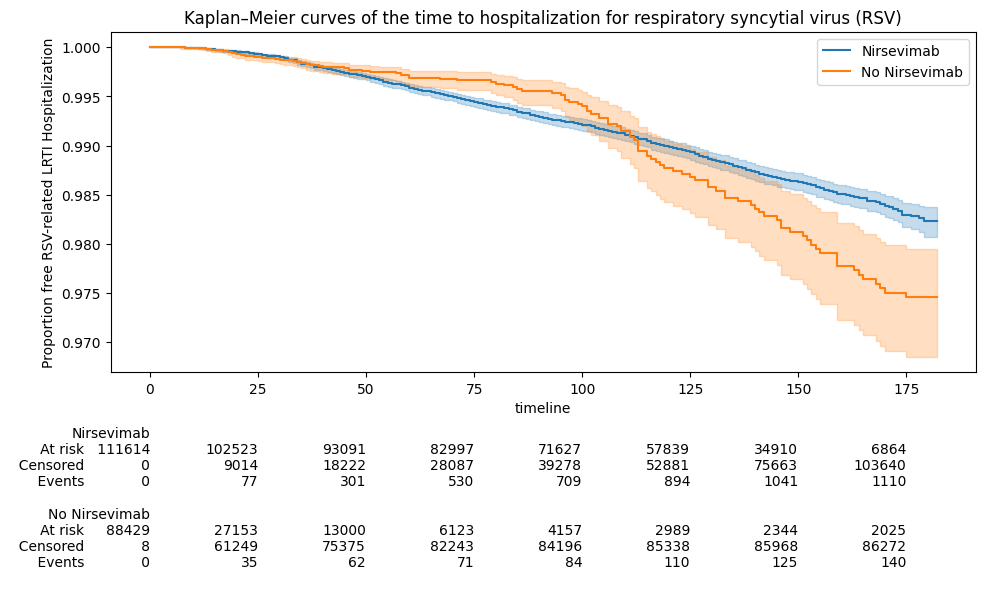

     test_statistic         p  -log2(p)
0 1        0.813897  0.366971  1.446263




,who,p_value
0,todo chile,0.367


this functions yields a plot KM and return 2 bbdd: df_mayer_vrs_agg, df_mayer_vrs


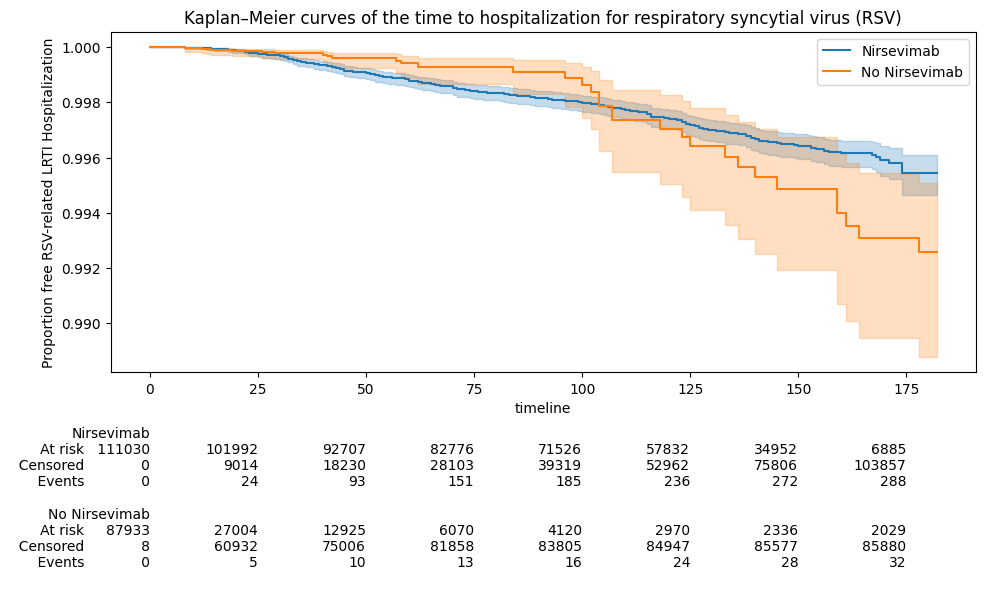

     test_statistic        p  -log2(p)
0 1         0.09995  0.75189  0.411407




,who,p_value
0,todo chile,0.752


In [115]:
##################### NO MATCHED KM #######################
df_mayer_vrs_agg_ag, df_mayer_vrs_ag = plot_extended_kaplan_meier(df_cox = df_cox_vrs_ag,
                                                            add_risk=True,
                                                            log_rank_test=True,
                                                            event = 'event_vrs')

df_mayer_upc_agg_ag, df_mayer_upc_ag = plot_extended_kaplan_meier(df_cox = df_cox_upc_ag,
                                                            add_risk=True,
                                                            log_rank_test=True,
                                                            event = 'event_upc')

this functions yields a plot KM and return 2 bbdd: df_mayer_vrs_agg, df_mayer_vrs


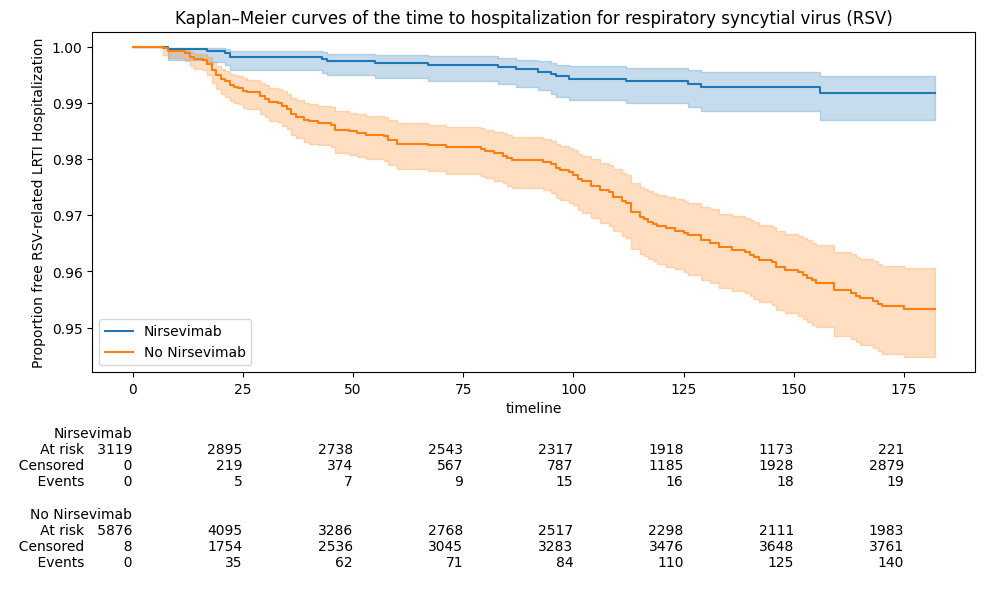

     test_statistic             p   -log2(p)
0 1         60.5078  7.328749e-15  46.955355




,who,p_value
0,todo chile,0.0


this functions yields a plot KM and return 2 bbdd: df_mayer_vrs_agg, df_mayer_vrs


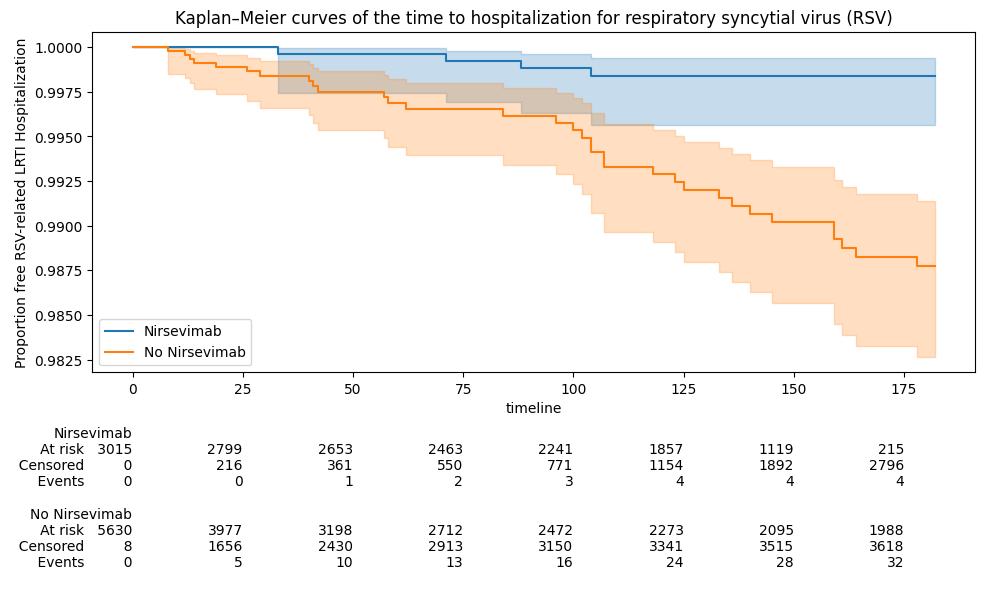

     test_statistic        p   -log2(p)
0 1       14.646908  0.00013  12.913122




,who,p_value
0,todo chile,0.0


In [ ]:
##################### MATCHED KM #######################
df_mayer_vrs_agg_ag, df_mayer_vrs_ag = plot_extended_kaplan_meier(df_cox = events_and_dataframes_matched_ag['event_vrs'].copy(),
                                                            add_risk=True,
                                                            log_rank_test=True,
                                                            event = 'event_vrs')

df_mayer_upc_agg_ag, df_mayer_upc_ag = plot_extended_kaplan_meier(df_cox = events_and_dataframes_matched_ag['event_upc'].copy(),
                                                            add_risk=True,
                                                            log_rank_test=True,
                                                            event = 'event_upc')